In [1]:
from typing import List, Dict, Optional
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from model_ranking.utils import (
    get_output_paths,
    load_h5,
)

Proportion non NaN patches = 1.00


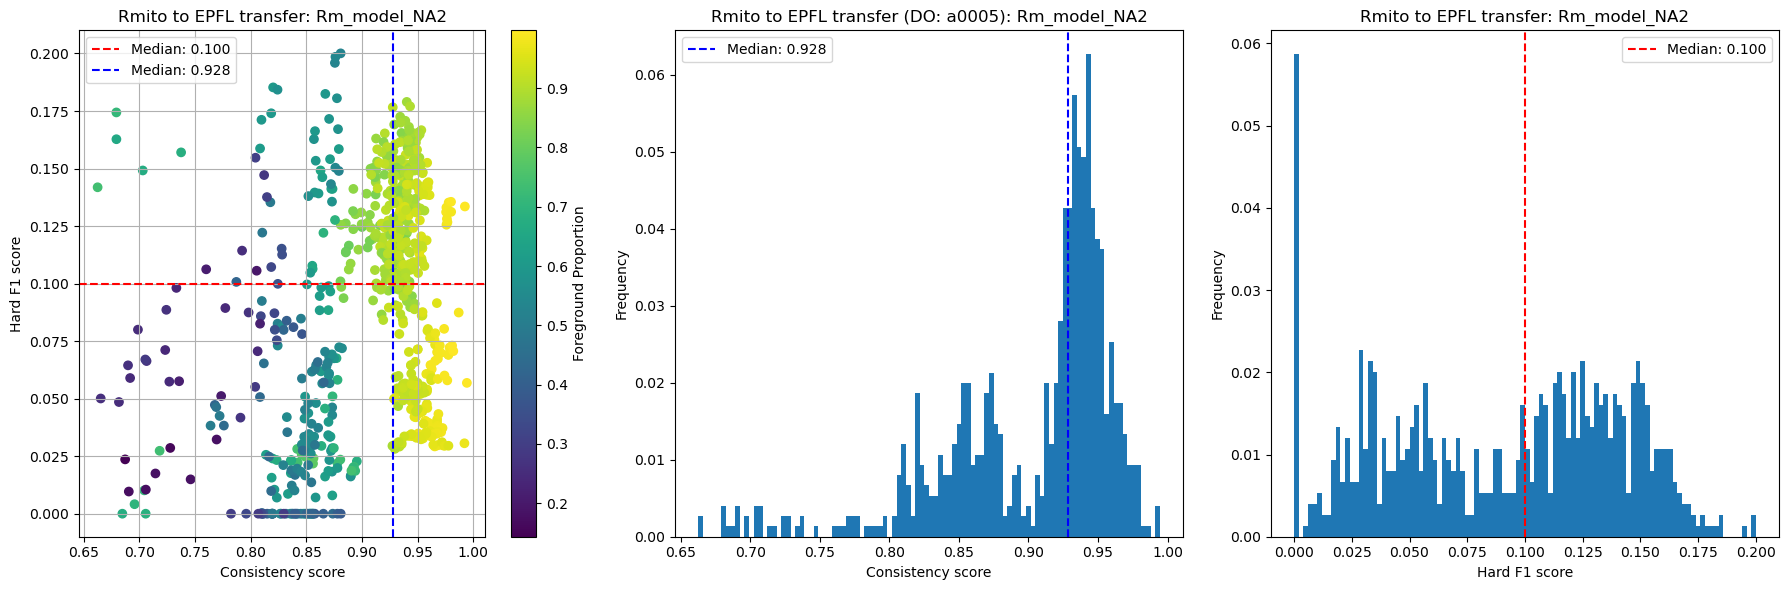

Proportion non NaN patches = 1.00


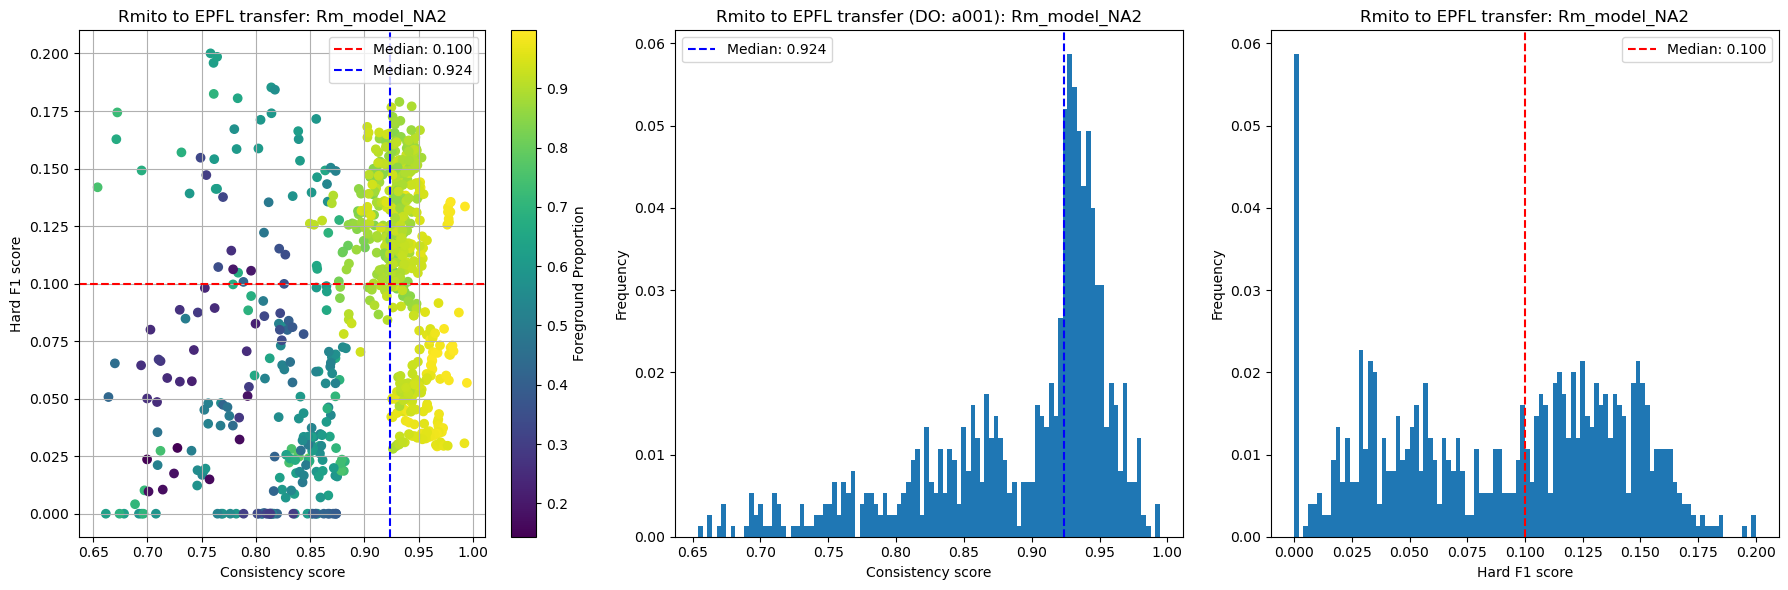

Proportion non NaN patches = 1.00


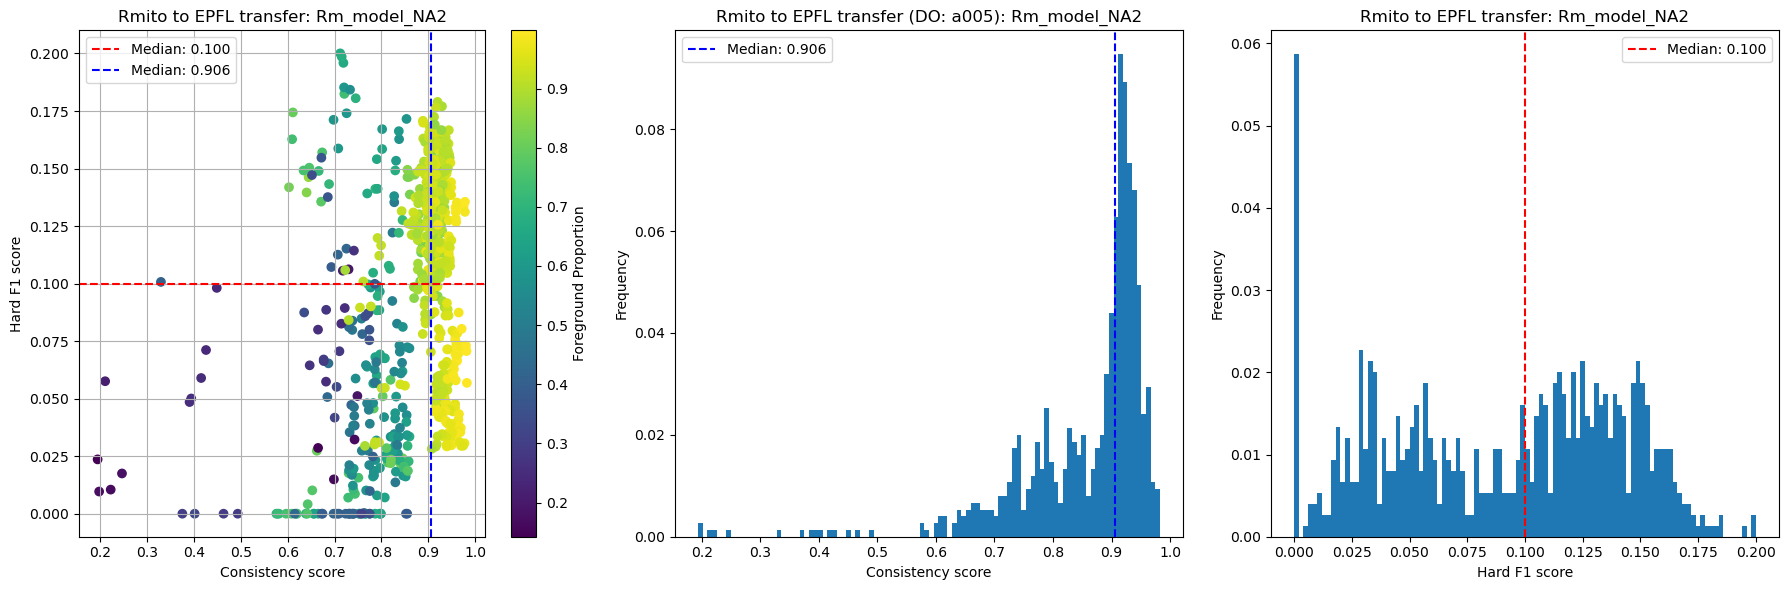

Proportion non NaN patches = 1.00


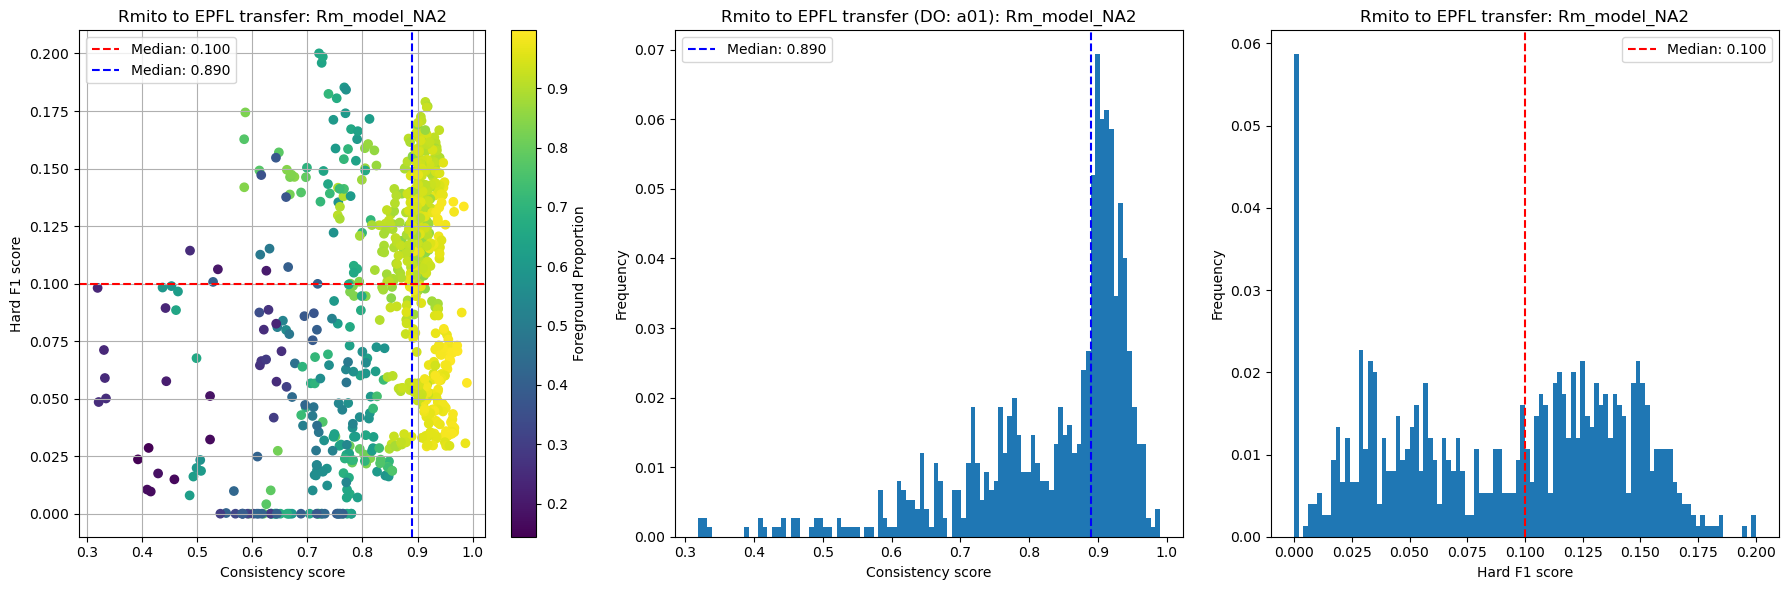

Proportion non NaN patches = 1.00


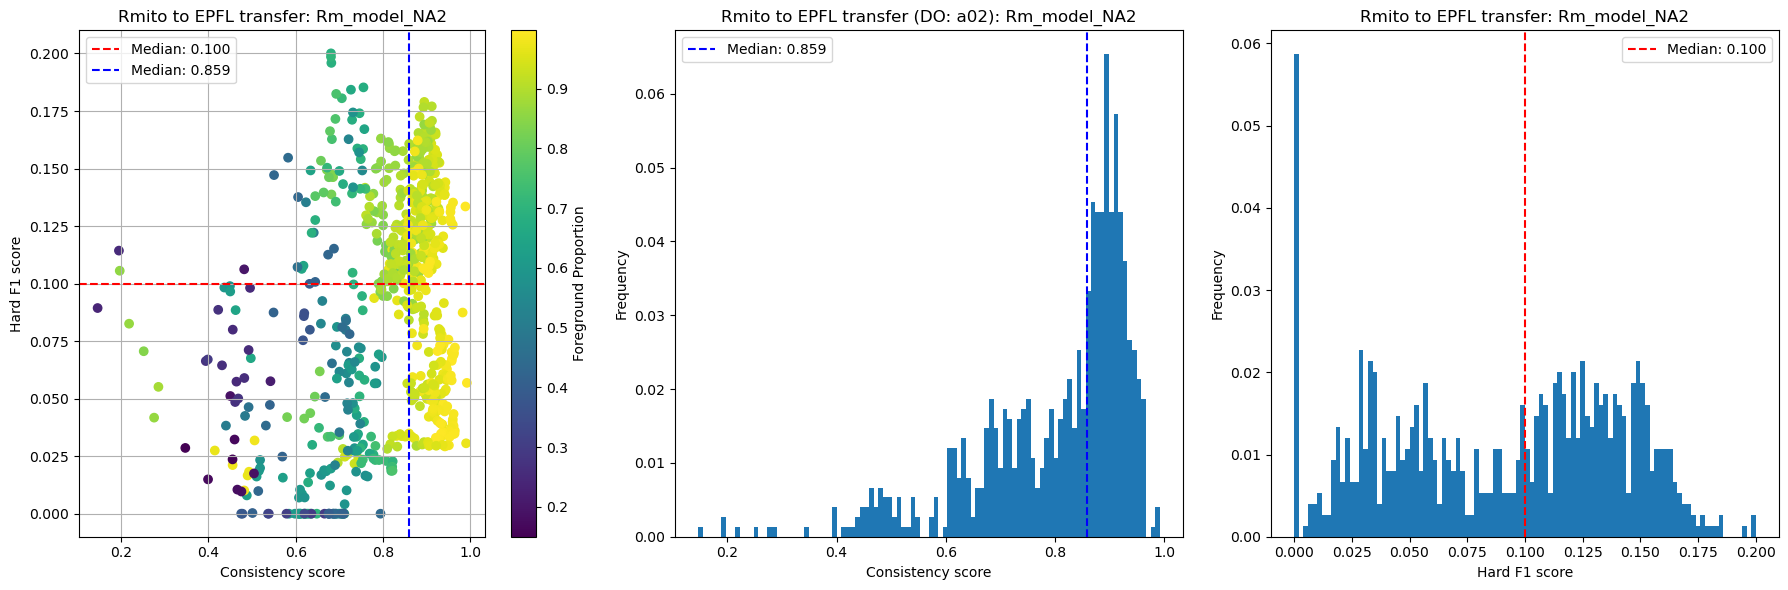

Proportion non NaN patches = 1.00


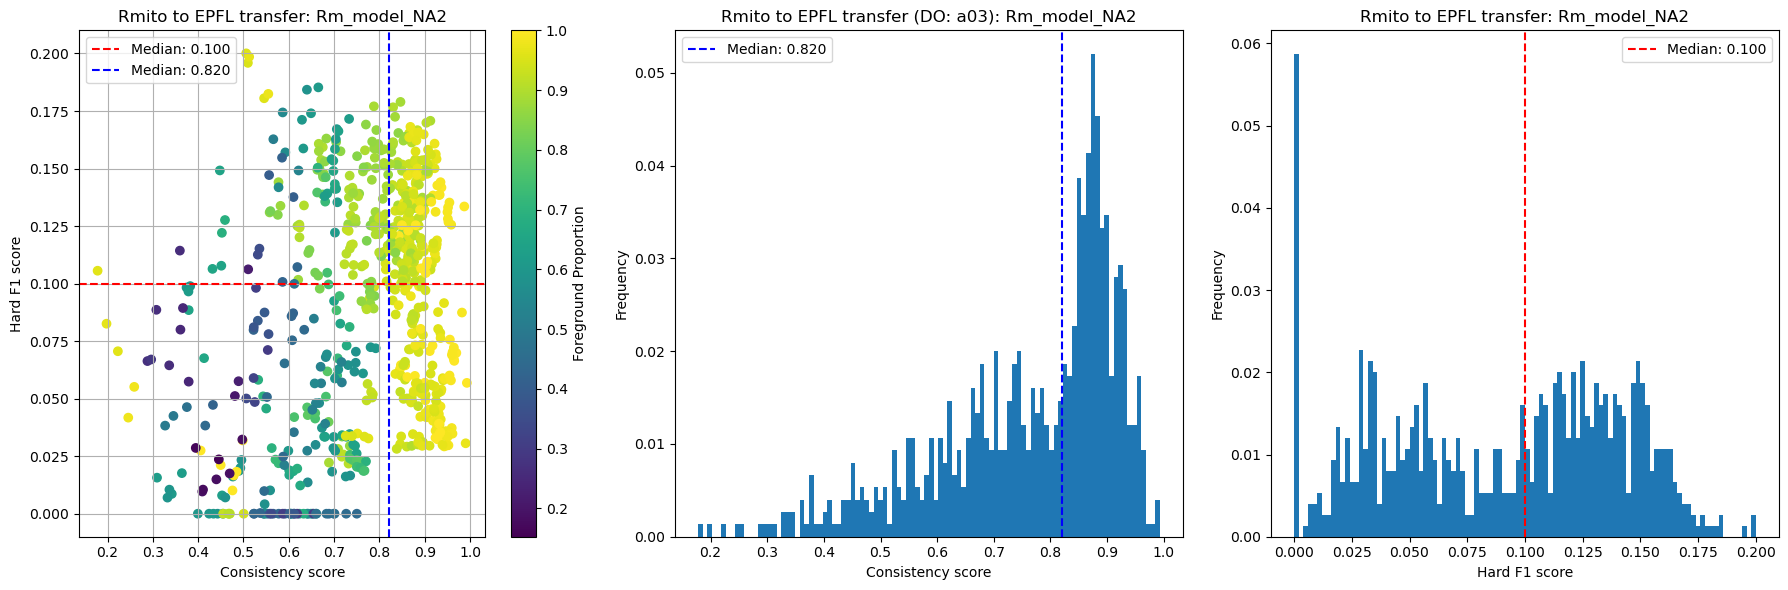

Proportion non NaN patches = 1.00


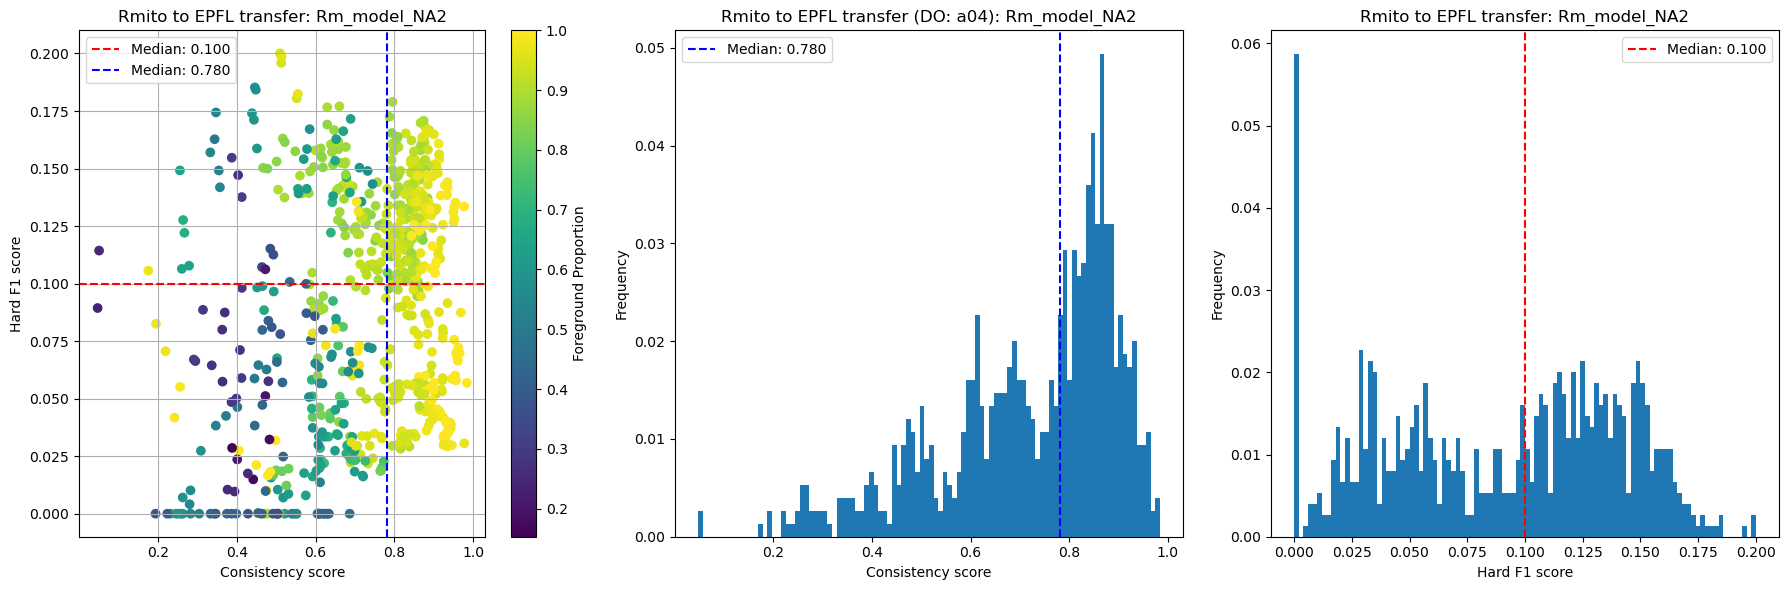

In [2]:
sources = {
    "Rmito": "Rm_model_NA2",
}
#targets = ["EPFL", "Hmito", "Rmito", "VNC"]
#targets = ["EPFL", "Hmito", "Rmito"]
targets=["EPFL"]
result_folders = {
    "EPFL": "FP_3",
    "Hmito": "FP_3",
    "Rmito": "FP_3",
    "VNC": "FP_3",
}
consis_key = "EI_consis"
selected_alphas = ["a0005", "a001", "a005", "a01", "a02", "a03", "a04"]
#targets = ["VNC"]
# foreground_thresholds: Optional[Dict[str, float]] = {
#     "EPFL": 0.04,
#     "Hmito": 0.04,
#     "Rmito": 0.04,
#     "VNC": 0.02,
# }
foreground_thresholds: Optional[Dict[str, float]] = None

for source, model_name in sources.items():
    for target in targets:
        none_paths = get_output_paths(
            source, 
            target, 
            {"none": []}, 
            [None], 
            model_name, 
            "predictions", 
            result_folder =result_folders[target], 
            base_dir_path="/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria"
        )
        assert len(none_paths) == 1, f"Expected one path for {source} to {target} transfer: {model_name}, found {len(paths)}"
        direct_pred_path: List[Path] = list(Path(none_paths[0]).glob("*.h5"))
        for i in range(len(direct_pred_path)):
            if "metric_summary" in direct_pred_path[i].name:
                _ = direct_pred_path.pop(i)
        eval_score_direct = load_h5(direct_pred_path[0], "hard_f1")[:,1]

        for perturbation_alpha in selected_alphas:

            DO_paths = get_output_paths(
                source, 
                target, 
                {"DO": [perturbation_alpha]}, 
                [None], 
                model_name, 
                "predictions", 
                result_folder = result_folders[target], 
                base_dir_path="/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria"
            )
            
            DO_pred_path: List[Path] = list(Path(DO_paths[0]).glob("*.h5"))
            for i in range(len(DO_pred_path)):
                if "metric_summary" in DO_pred_path[i].name:
                    _ = DO_pred_path.pop(i)
        
            consis_score_direct = load_h5(DO_pred_path[0], consis_key)
            consis_score_PP = np.nanmean(consis_score_direct, axis=tuple(range(1, consis_score_direct.ndim)))
            foreground_proportions = np.count_nonzero(~np.isnan(consis_score_direct), axis=(1,2))/consis_score_direct[0].size
            if foreground_thresholds is not None:
                sel_ids = np.where(foreground_proportions > foreground_thresholds[source])[0]
                consis_score_PP = consis_score_PP[sel_ids]
                eval_score_direct = eval_score_direct[sel_ids]
                foreground_proportions = foreground_proportions[sel_ids]
                eval_direct_median = np.nanmedian(eval_score_direct, axis=0)
                consis_median = np.nanmedian(consis_score_PP, axis=0)
            else:
                eval_direct_median = np.nanmedian(eval_score_direct, axis=0)
                consis_median = np.nanmedian(consis_score_PP, axis=0)

            print(f"Proportion non NaN patches = {(len(consis_score_PP) - np.isnan(consis_score_PP).sum()) / len(consis_score_PP):.2f}")
            _, axs = plt.subplots(1, 3, figsize=(18, 6))
            sc = axs[0].scatter(consis_score_PP, eval_score_direct, c=foreground_proportions, cmap='viridis')
            _ = axs[0].set_xlabel("Consistency score")
            _ = plt.colorbar(sc, ax=axs[0], label='Foreground Proportion')
            _ = axs[0].set_ylabel("Hard F1 score")
            _ = axs[0].grid()
            _ = axs[0].set_title(f"{source} to {target} transfer: {model_name}")
            _ = axs[0].axhline(eval_direct_median, color="red", linestyle="--", label="Median: {:.3f}".format(eval_direct_median))
            _ = axs[0].axvline(consis_median, color="blue", linestyle="--", label="Median: {:.3f}".format(consis_median))
            _ = axs[0].legend()
            _ = axs[1].hist(consis_score_PP, bins=100, weights=np.ones_like(consis_score_PP) / len(consis_score_PP))
            _ = axs[1].set_title(f"{source} to {target} transfer (DO: {perturbation_alpha}): {model_name}")
            _ = axs[1].set_xlabel("Consistency score")
            _ = axs[1].set_ylabel("Frequency")
            _ = axs[1].axvline(consis_median, color="blue", linestyle="--", label="Median: {:.3f}".format(consis_median))
            _ = axs[1].legend()
            _ = axs[2].hist(eval_score_direct, bins=100, weights=np.ones_like(eval_score_direct) / len(eval_score_direct))
            _ = axs[2].axvline(eval_direct_median, color="red", linestyle="--", label="Median: {:.3f}".format(eval_direct_median))
            _ = axs[2].legend()
            _ = axs[2].set_title(f"{source} to {target} transfer: {model_name}")
            _ = axs[2].set_xlabel("Hard F1 score")
            _ = axs[2].set_ylabel("Frequency")
            plt.tight_layout()
            plt.show()
        

In [6]:
E_path = "/scratch/talks/data/EPFL/test.h5"
E_data = load_h5(E_path, "labels")

In [3]:
RtoE_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/Rmito_to_EPFL_gap/feature_perturbation_consistency/FP_3/Rm_model_NA2/norm_Normalize/DO_a02/predictions/test_predictions.h5"
RtoE_preds = load_h5(RtoE_path, "predictions")
RtoE_patch_indexes = load_h5(RtoE_path, "patch_index")
RtoE_f1_Scores = load_h5(RtoE_path, "hard_f1")
RtoE_consis = load_h5(RtoE_path, "EI_consis")

In [4]:
consis_score_PP = np.nanmean(RtoE_consis, axis=tuple(range(1, RtoE_consis.ndim)))
ids_c09 = np.where(consis_score_PP >0.9)[0]

In [5]:
print(len(ids_c09))

206


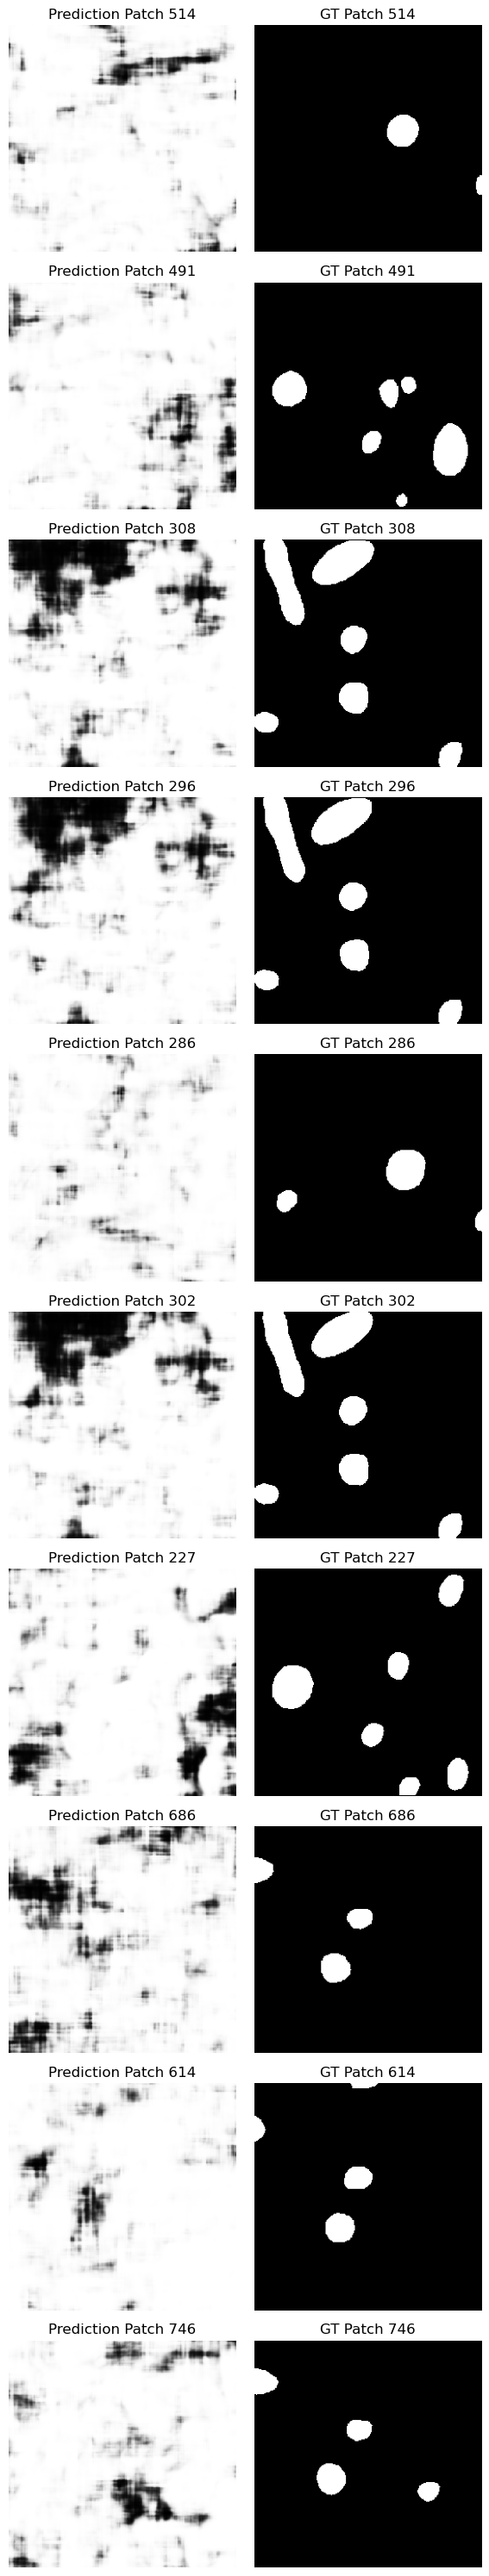

In [7]:
# Set random seed for reproducibility
np.random.seed(10)

# Randomly select 10 patch indices from ids_zero
sample_indices = np.random.choice(ids_c09, size=10, replace=False)

fig, axes = plt.subplots(len(sample_indices), 2, figsize=(6, 3 * len(sample_indices)))

for i, idx in enumerate(sample_indices):
    # Get patch coordinates
    z, y, x = RtoE_patch_indexes[idx]
    # Extract prediction and ground truth patch
    pred_patch = RtoE_preds[idx, 0, 0]
    gt_patch = E_data[z[0]:z[1], y[0]:y[1], x[0]:x[1]]

    # Plot prediction
    axes[i, 0].imshow(pred_patch.squeeze(), cmap='gray')
    axes[i, 0].set_title(f'Prediction Patch {idx}')
    axes[i, 0].axis('off')

    # Plot ground truth
    axes[i, 1].imshow(gt_patch.squeeze(), cmap='gray')
    axes[i, 1].set_title(f'GT Patch {idx}')
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()